In [ ]:
# Analyse du marché IT au Maroc – Requêtes DuckDB

Ce notebook répond aux 5 questions analytiques et inclut les visualisations du dashboard.

In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Connexion DuckDB
con = duckdb.connect()

In [4]:
## Dashboard de synthèse (4 visualisations)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17516\4048817767.py:12: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig1 = px.scatter_mapbox(df_carte, lat='lat', lon='lon', size='nb_offres',


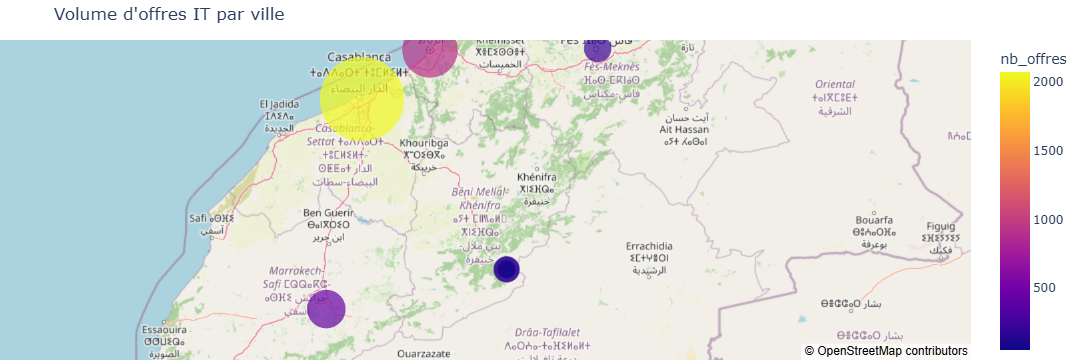

In [5]:
# 1. Carte des offres par ville
df_ville = pd.read_parquet('data_lake_root/gold/offres_par_ville.parquet')
df_carte = df_ville.groupby('ville')['nb_offres'].sum().reset_index()
coords = {
    'Casablanca': (33.5731, -7.5898), 'Rabat': (34.0209, -6.8416),
    'Tanger': (35.7595, -5.8340), 'Marrakech': (31.6295, -7.9811),
    'Fès': (34.0333, -5.0000), 'Inconnue': (32.0, -6.0)
}
df_carte['lat'] = df_carte['ville'].map(lambda v: coords.get(v, (32.0, -6.0))[0])
df_carte['lon'] = df_carte['ville'].map(lambda v: coords.get(v, (32.0, -6.0))[1])

fig1 = px.scatter_mapbox(df_carte, lat='lat', lon='lon', size='nb_offres',
                         color='nb_offres', hover_name='ville',
                         size_max=60, zoom=6,
                         title="Volume d'offres IT par ville",
                         mapbox_style='open-street-map')
fig1.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig1.show()

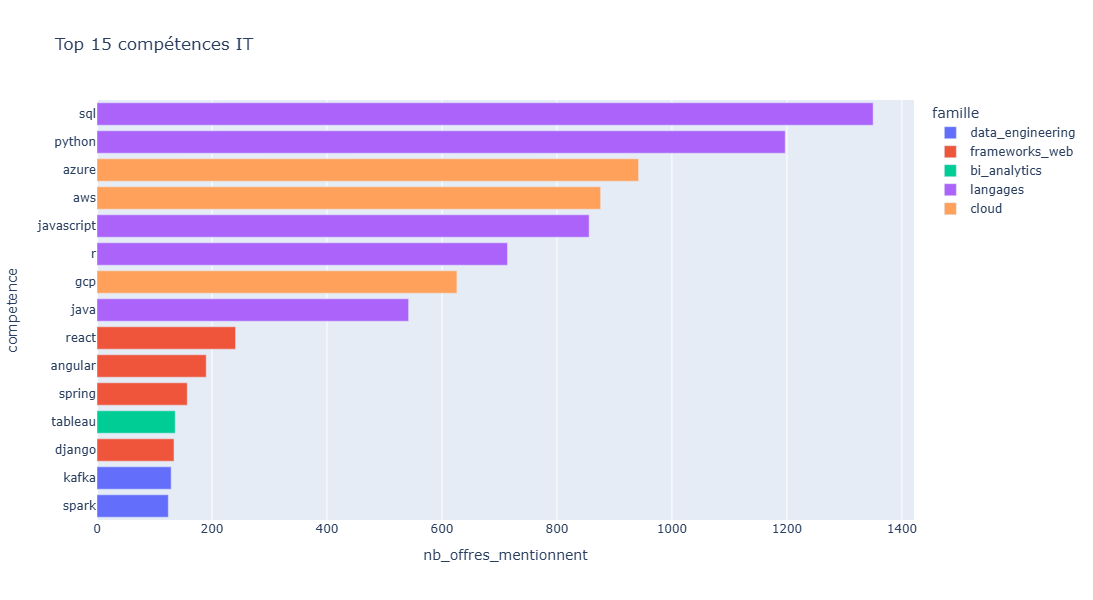

In [6]:
# 2. Top 15 compétences
df_comp = pd.read_parquet('data_lake_root/gold/top_competences.parquet')
top15 = df_comp.groupby(['competence','famille'])['nb_offres_mentionnent'].sum().nlargest(15).reset_index()
top15 = top15.sort_values('nb_offres_mentionnent', ascending=True)
fig2 = px.bar(top15, y='competence', x='nb_offres_mentionnent', color='famille',
              orientation='h', title='Top 15 compétences IT')
fig2.update_layout(yaxis={'categoryorder':'total ascending'}, height=600)
fig2.show()

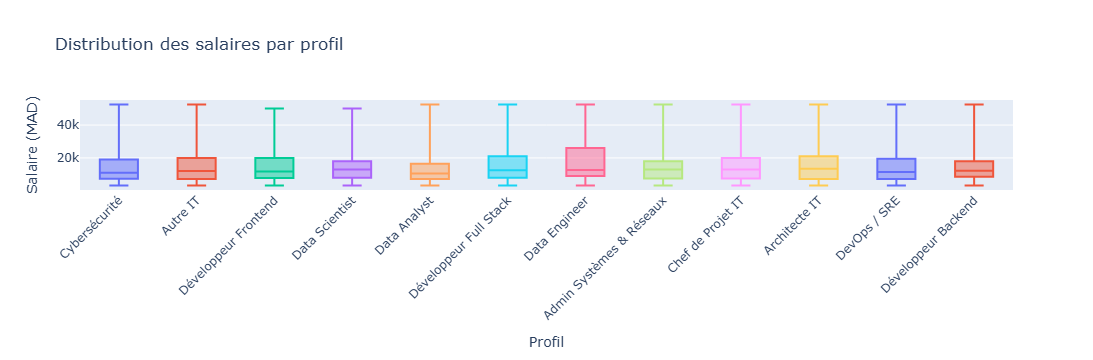

In [7]:
# 3. Boxplot salaires (à partir des données individuelles Silver)
df_offres = pd.read_parquet('data_lake_root/silver/offres_clean/offres_clean.parquet')
df_box = df_offres[df_offres['salaire_connu'] & (df_offres['salaire_median_mad'] > 0)]
profils_5plus = df_box['profil_normalise'].value_counts()[df_box['profil_normalise'].value_counts() >= 5].index
df_box = df_box[df_box['profil_normalise'].isin(profils_5plus)]

fig3 = px.box(df_box, x='profil_normalise', y='salaire_median_mad',
              title='Distribution des salaires par profil',
              labels={'profil_normalise':'Profil', 'salaire_median_mad':'Salaire (MAD)'},
              color='profil_normalise', points=False)
fig3.update_layout(showlegend=False, xaxis_tickangle=-45)
fig3.show()

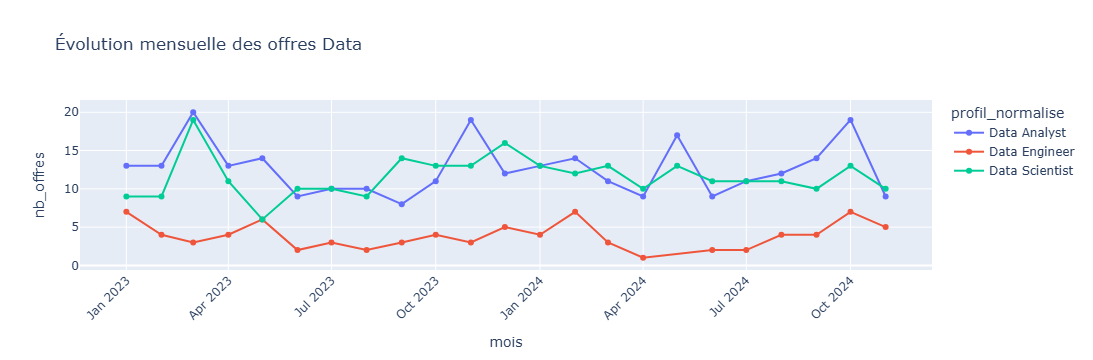

In [8]:
# 4. Évolution mensuelle Data Engineer / Data Analyst / Data Scientist
df_offres['date'] = pd.to_datetime(df_offres['date_publication'])
df_offres['mois'] = df_offres['date'].dt.to_period('M').astype(str)
profil_data = ['Data Engineer', 'Data Analyst', 'Data Scientist']
df_evol = df_offres[df_offres['profil_normalise'].isin(profil_data)]
evol = df_evol.groupby(['mois', 'profil_normalise']).size().reset_index(name='nb_offres')
fig4 = px.line(evol, x='mois', y='nb_offres', color='profil_normalise',
               title='Évolution mensuelle des offres Data',
               markers=True)
fig4.update_layout(xaxis_tickangle=-45)
fig4.show()